# Pix2Pix Training


## Introduction

The previous notebook established a non-adversarial U-Net baseline for reconstructing furniture images from paired edge maps. Although the model recovered coarse object shape and spatial structure, its pixel-wise $L_1$ objective produced blurred and desaturated predictions with limited texture and fine detail.

This notebook trains a newly initialized instance of the same U-Net generator architecture within the Pix2Pix framework, together with a PatchGAN discriminator. No weights are transferred from the reconstruction baseline. The generator is trained using a combination of adversarial loss, which encourages locally realistic image content, and $L_1$ reconstruction loss, which promotes structural and colour similarity to the target image. The discriminator learns to distinguish real edge-image pairs from pairs containing generated images.

The complete Pix2Pix pipeline is constructed and verified before pilot and full training. Training progress is preserved through checkpoints, and the resulting model is inspected using the same fixed validation examples selected for the U-Net baseline. The test split remains untouched for the formal evaluation and comparison performed in a later notebook.

## Setup and Environment

In [2]:
# Import Libraries

import json
import random
import subprocess
import tarfile
import time
from pathlib import Path

import gc

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms.functional as TF

from google.colab import drive
from PIL import Image
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from tqdm.auto import tqdm

In [3]:
# Configure Reproducibility and Device

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = False
torch.backends.cudnn.benchmark = True

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

USE_AMP = DEVICE.type == "cuda"
AMP_DTYPE = torch.float16

print(f"PyTorch version: {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")
print(f"Device: {DEVICE}")
print(f"Mixed precision enabled: {USE_AMP}")
print(f"Mixed-precision dtype: {AMP_DTYPE}")

if torch.cuda.is_available():
    print(
        "GPU: "
        f"{torch.cuda.get_device_name(0)}"
    )

    gpu_status = subprocess.run(
        [
            "nvidia-smi",
            "--query-gpu=memory.total,memory.used,memory.free",
            "--format=csv,noheader",
        ],
        capture_output=True,
        text=True,
        check=False,
    )

    print(f"GPU memory: {gpu_status.stdout.strip()}")

PyTorch version: 2.11.0+cu128
Torchvision version: 0.26.0+cu128
Device: cuda
Mixed precision enabled: True
Mixed-precision dtype: torch.float16
GPU: Tesla T4
GPU memory: 15360 MiB, 3 MiB, 14910 MiB


In [4]:
# Mount Google Drive

drive.mount("/content/drive")

Mounted at /content/drive


In [5]:
# Define Project Paths


DRIVE_ROOT = Path(
    "/content/drive/MyDrive/Sketch2Furniture"
)

FIGURE_DIR = DRIVE_ROOT / "figures"

FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

ARCHIVE_PATH = (
    DRIVE_ROOT / "colab_data" / "paired_dataset.tar"
)

# Keeping Pix2Pix artifacts separate from the U-Net baseline
CKPT_DIR = (
    DRIVE_ROOT / "checkpoints" / "pix2pix"
)

LOCAL_ROOT = Path("/content")

PAIRED_DATA_DIR = (
    LOCAL_ROOT / "data" / "processed" / "paired"
)

PREPARED_METADATA_PATH = (
    PAIRED_DATA_DIR / "prepared_metadata.csv"
)

EXTRACTION_MARKER = (
    PAIRED_DATA_DIR / ".extraction_complete"
)

if not DRIVE_ROOT.is_dir():
    raise FileNotFoundError(
        f"Drive project folder not found: {DRIVE_ROOT}"
    )

if not ARCHIVE_PATH.is_file():
    raise FileNotFoundError(
        f"Prepared dataset archive not found: {ARCHIVE_PATH}"
    )

CKPT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

print(f"Drive project root: {DRIVE_ROOT}")
print(f"Prepared archive: {ARCHIVE_PATH}")
print(f"Pix2Pix checkpoint directory: {CKPT_DIR}")
print(f"Local paired-data directory: {PAIRED_DATA_DIR}")

Drive project root: /content/drive/MyDrive/Sketch2Furniture
Prepared archive: /content/drive/MyDrive/Sketch2Furniture/colab_data/paired_dataset.tar
Pix2Pix checkpoint directory: /content/drive/MyDrive/Sketch2Furniture/checkpoints/pix2pix
Local paired-data directory: /content/data/processed/paired


## Dataset and Data Loaders


In [6]:
# Extract Prepared Dataset

if (
    EXTRACTION_MARKER.is_file()
    and PREPARED_METADATA_PATH.is_file()
):
    print("Prepared dataset is already extracted.")
else:
    print("Extracting prepared dataset...")

    with tarfile.open(ARCHIVE_PATH, mode="r") as archive:
        archive.extractall(
            path=LOCAL_ROOT,
            filter="data",
        )

    if not PREPARED_METADATA_PATH.is_file():
        raise FileNotFoundError(
            "Prepared metadata was not found after extraction: "
            f"{PREPARED_METADATA_PATH}"
        )

    EXTRACTION_MARKER.touch()

    print("Prepared dataset extracted successfully.")

print(f"Prepared metadata: {PREPARED_METADATA_PATH}")
print(f"Extraction marker: {EXTRACTION_MARKER}")

Extracting prepared dataset...
Prepared dataset extracted successfully.
Prepared metadata: /content/data/processed/paired/prepared_metadata.csv
Extraction marker: /content/data/processed/paired/.extraction_complete


In [7]:
# Load and Verify Prepared Metadata

prepared_metadata = pd.read_csv(PREPARED_METADATA_PATH)

if prepared_metadata.empty:
    raise ValueError("Prepared metadata is empty.")

IMAGE_SUFFIXES = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp",
}

prepared_image_paths = [
    path
    for path in PAIRED_DATA_DIR.rglob("*")
    if (
        path.is_file()
        and path.suffix.lower() in IMAGE_SUFFIXES
    )
]

actual_image_count = len(prepared_image_paths)
expected_image_count = 2 * len(prepared_metadata)

if actual_image_count < expected_image_count:
    raise ValueError("Fewer image files than the metadata requires.")

extra_image_count = (actual_image_count - expected_image_count)

if extra_image_count % 2 != 0:
    raise ValueError("The additional image files do not form complete pairs.")

excluded_pairs = extra_image_count // 2

print(f"Metadata rows: {len(prepared_metadata)}")
print(f"Prepared image files: {actual_image_count}")
print(f"Expected image files: {expected_image_count}")
print(f"Pairs on disk but excluded from metadata: {excluded_pairs}")
print(f"Metadata columns: {prepared_metadata.columns.tolist()}")

display(prepared_metadata.head())

Metadata rows: 14318
Prepared image files: 28668
Expected image files: 28636
Pairs on disk but excluded from metadata: 16
Metadata columns: ['split', 'relative_path', 'category', 'style', 'directory_style', 'product_subtype', 'metadata_style', 'metadata_attributes', 'styles_match', 'metadata_field_count', 'product_subtype_normalized', 'filename_descriptor', 'filename_descriptor_normalized', 'file_exists', 'image_readable', 'width', 'height', 'image_mode', 'image_format', 'file_size_bytes', 'sha256', 'perceptual_hash', 'inspection_error', 'source_path', 'source_exists', 'pair_id', 'input_path', 'target_path', 'generation_success', 'generation_error']


,split,relative_path,category,style,directory_style,product_subtype,metadata_style,metadata_attributes,styles_match,metadata_field_count,...,sha256,perceptual_hash,inspection_error,source_path,source_exists,pair_id,input_path,target_path,generation_success,generation_error
0,train,houzz/beds/Asian/19726asian-daybeds.jpg,beds,Asian,Asian,beds,Asian,NaN,True,2,...,2bad3ff85cab5b13c38e0cac29b75ea57258e14088f620...,ee74e91ac52496e1,NaN,/home/vanya/projects/SoftUni-Studies/Sketch2Fu...,True,pair_00001,/home/vanya/projects/SoftUni-Studies/Sketch2Fu...,/home/vanya/projects/SoftUni-Studies/Sketch2Fu...,True,NaN
1,train,houzz/beds/Asian/20027asian-canopy-beds.jpg,beds,Asian,Asian,beds,Asian,NaN,True,2,...,abc4eff61c5b60a7618b4d86d5ead6b5a43a899ba278a8...,e581b91de46a94ad,NaN,/home/vanya/projects/SoftUni-Studies/Sketch2Fu...,True,pair_00002,/home/vanya/projects/SoftUni-Studies/Sketch2Fu...,/home/vanya/projects/SoftUni-Studies/Sketch2Fu...,True,NaN
2,train,houzz/beds/Asian/20109asian-panel-beds.jpg,beds,Asian,Asian,beds,Asian,NaN,True,2,...,4b90bb2a43d82aeef3830f40b91ebc1e63758e4083a379...,ee53c4291a7de9a0,NaN,/home/vanya/projects/SoftUni-Studies/Sketch2Fu...,True,pair_00003,/home/vanya/projects/SoftUni-Studies/Sketch2Fu...,/home/vanya/projects/SoftUni-Studies/Sketch2Fu...,True,NaN
3,train,houzz/beds/Asian/20508asian-platform-beds.jpg,beds,Asian,Asian,beds,Asian,NaN,True,2,...,ebaf5abbd2e00d53a484574a24eb6233793ebb68bf40df...,bf19e0708cc6e8d6,NaN,/home/vanya/projects/SoftUni-Studies/Sketch2Fu...,True,pair_00004,/home/vanya/projects/SoftUni-Studies/Sketch2Fu...,/home/vanya/projects/SoftUni-Studies/Sketch2Fu...,True,NaN
4,validation,houzz/beds/Asian/20750asian-comforters-and-com...,beds,Asian,Asian,beds,Asian,NaN,True,2,...,8a6de9f497a401536cfab5e243e5ede7e68c035cf7804c...,aaa4a876c0c8e57f,NaN,/home/vanya/projects/SoftUni-Studies/Sketch2Fu...,True,pair_00005,/home/vanya/projects/SoftUni-Studies/Sketch2Fu...,/home/vanya/projects/SoftUni-Studies/Sketch2Fu...,True,NaN


In [8]:
# Rebuild Prepared Paths and Verify Files

def rebuild_colab_path(stored_path):
    stored_path = Path(stored_path)
    path_parts = stored_path.parts

    paired_positions = [
        index
        for index, part in enumerate(path_parts)
        if part == PAIRED_DATA_DIR.name
    ]

    if not paired_positions:
        raise ValueError(
            "Could not locate the paired-data directory "
            f"in stored path: {stored_path}"
        )

    paired_index = paired_positions[-1]
    relative_parts = path_parts[paired_index + 1:]

    return str(
        PAIRED_DATA_DIR.joinpath(*relative_parts)
    )


prepared_metadata["input_path"] = (
    prepared_metadata["input_path"].map(
        rebuild_colab_path
    )
)

prepared_metadata["target_path"] = (
    prepared_metadata["target_path"].map(
        rebuild_colab_path
    )
)

input_exists = prepared_metadata["input_path"].map(
    lambda path: Path(path).is_file()
)

target_exists = prepared_metadata["target_path"].map(
    lambda path: Path(path).is_file()
)

pair_exists = input_exists & target_exists

print(f"Metadata pairs: {len(prepared_metadata)}")
print(f"Missing input files: {(~input_exists).sum()}")
print(f"Missing target files: {(~target_exists).sum()}")
print(f"Verified metadata pairs: {pair_exists.sum()}")

if not pair_exists.all():
    display(
        prepared_metadata.loc[
            ~pair_exists,
            [
                "pair_id",
                "split",
                "input_path",
                "target_path",
            ],
        ].head()
    )

    raise FileNotFoundError(
        "One or more metadata-referenced image pairs "
        "could not be found."
    )

Metadata pairs: 14318
Missing input files: 0
Missing target files: 0
Verified metadata pairs: 14318


In [9]:
# Create Training and Validation Metadata

EXPECTED_SPLITS = [
    "train",
    "validation",
    "test",
]

observed_splits = set(prepared_metadata["split"].unique())

unexpected_splits = (observed_splits - set(EXPECTED_SPLITS))

missing_splits = (set(EXPECTED_SPLITS) - observed_splits)

if unexpected_splits:
    raise ValueError(f"Unexpected split labels: {unexpected_splits}")

if missing_splits:
    raise ValueError(f"Expected split labels are missing: {missing_splits}")

if prepared_metadata["pair_id"].duplicated().any():
    raise ValueError("Duplicate pair IDs were found in the metadata.")

split_counts = (
    prepared_metadata["split"]
    .value_counts()
    .reindex(
        EXPECTED_SPLITS,
        fill_value=0,
    )
)

train_metadata = (
    prepared_metadata.loc[
        prepared_metadata["split"] == "train"
    ]
    .reset_index(drop=True)
)

validation_metadata = (
    prepared_metadata.loc[
        prepared_metadata["split"] == "validation"
    ]
    .reset_index(drop=True)
)

if train_metadata.empty:
    raise ValueError("The training metadata is empty.")

if validation_metadata.empty:
    raise ValueError("The validation metadata is empty.")

print(f"Training pairs: {len(train_metadata)}")
print(f"Validation pairs: {len(validation_metadata)}")
print(f"Test pairs reserved: {split_counts['test']}")
print(f"Total metadata pairs: {split_counts.sum()}")

Training pairs: 9718
Validation pairs: 1708
Test pairs reserved: 2892
Total metadata pairs: 14318


The paired dataset loads each edge map as a grayscale input and its corresponding furniture image as an RGB target. It preserves the U-Net baseline preprocessing by randomly applying a synchronized horizontal flip to training pairs and normalizing both images to $[-1,1]$, ensuring a consistent comparison between the two models.

In [10]:
# Define Paired Furniture Dataset

class PairedFurnitureDataset(Dataset):
    def __init__(
        self,
        metadata,
        augment=False,
    ):
        self.metadata = (
            metadata
            .reset_index(drop=True)
            .copy()
        )
        self.augment = augment

    def __len__(self):
        return len(self.metadata)

    def __getitem__(self, index):
        row = self.metadata.iloc[index]

        with Image.open(row["input_path"]) as image:
            input_image = image.convert("L")

        with Image.open(row["target_path"]) as image:
            target_image = image.convert("RGB")

        if (self.augment and torch.rand(1).item() < 0.5):
            input_image = TF.hflip(input_image)
            target_image = TF.hflip(target_image)

        input_tensor = (
            TF.to_tensor(input_image)
            .mul(2)
            .sub(1)
        )

        target_tensor = (
            TF.to_tensor(target_image)
            .mul(2)
            .sub(1)
        )

        return {
            "input": input_tensor,
            "target": target_tensor,
            "pair_id": row["pair_id"],
        }

In [11]:
# Create and Verify Training and Validation Datasets

train_dataset = PairedFurnitureDataset(
    metadata=train_metadata,
    augment=True,
)

validation_dataset = PairedFurnitureDataset(
    metadata=validation_metadata,
    augment=False,
)

validation_sample = validation_dataset[0]

expected_input_shape = (1, 256, 256)
expected_target_shape = (3, 256, 256)

if validation_sample["input"].shape != expected_input_shape:
    raise ValueError(
        "Unexpected input shape: "
        f"{validation_sample['input'].shape}"
    )

if validation_sample["target"].shape != expected_target_shape:
    raise ValueError(
        "Unexpected target shape: "
        f"{validation_sample['target'].shape}"
    )

for tensor_name in ["input", "target"]:
    tensor = validation_sample[tensor_name]

    if tensor.min() < -1 or tensor.max() > 1:
        raise ValueError(
            f"{tensor_name} is outside the expected [-1, 1] range."
        )

print(f"Training dataset size: {len(train_dataset)}")
print(
    "Validation dataset size: "
    f"{len(validation_dataset)}"
)
print(
    "Validation input shape: "
    f"{validation_sample['input'].shape}"
)
print(
    "Validation target shape: "
    f"{validation_sample['target'].shape}"
)
print(
    "Input value range: "
    f"[{validation_sample['input'].min():.1f}, "
    f"{validation_sample['input'].max():.1f}]"
)
print(
    "Target value range: "
    f"[{validation_sample['target'].min():.1f}, "
    f"{validation_sample['target'].max():.1f}]"
)
print(
    "Sample pair ID: "
    f"{validation_sample['pair_id']}"
)

Training dataset size: 9718
Validation dataset size: 1708
Validation input shape: torch.Size([1, 256, 256])
Validation target shape: torch.Size([3, 256, 256])
Input value range: [-1.0, 1.0]
Target value range: [-1.0, 1.0]
Sample pair ID: pair_00005


The training loader shuffles the augmented training pairs, while the validation loader preserves a fixed order and applies no augmentation. Pinned memory speeds up transfers to the GPU, and persistent workers avoid restarting the data-loading processes at every epoch.

In [12]:
# Create Training and Validation Data Loaders

BATCH_SIZE = 8
NUM_WORKERS = 2
PIN_MEMORY = DEVICE.type == "cuda"

train_loader_generator = torch.Generator()
train_loader_generator.manual_seed(SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    drop_last=False,
    persistent_workers=NUM_WORKERS > 0,
    generator=train_loader_generator,
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    drop_last=False,
    persistent_workers=NUM_WORKERS > 0,
)

validation_batch = next(iter(validation_loader))

print(f"Batch size: {BATCH_SIZE}")
print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(validation_loader)}")
print(f"Validation input batch shape: {validation_batch['input'].shape}")
print(f"Validation target batch shape: {validation_batch['target'].shape}")
print(f"First validation pair ID: {validation_batch['pair_id'][0]}")

Batch size: 8
Training batches: 1215
Validation batches: 214
Validation input batch shape: torch.Size([8, 1, 256, 256])
Validation target batch shape: torch.Size([8, 3, 256, 256])
First validation pair ID: pair_00005


A validation batch is visualized to confirm that the edge maps remain correctly aligned with their target furniture images after loading and normalization. Validation examples are used because their order is fixed and no augmentation is applied.

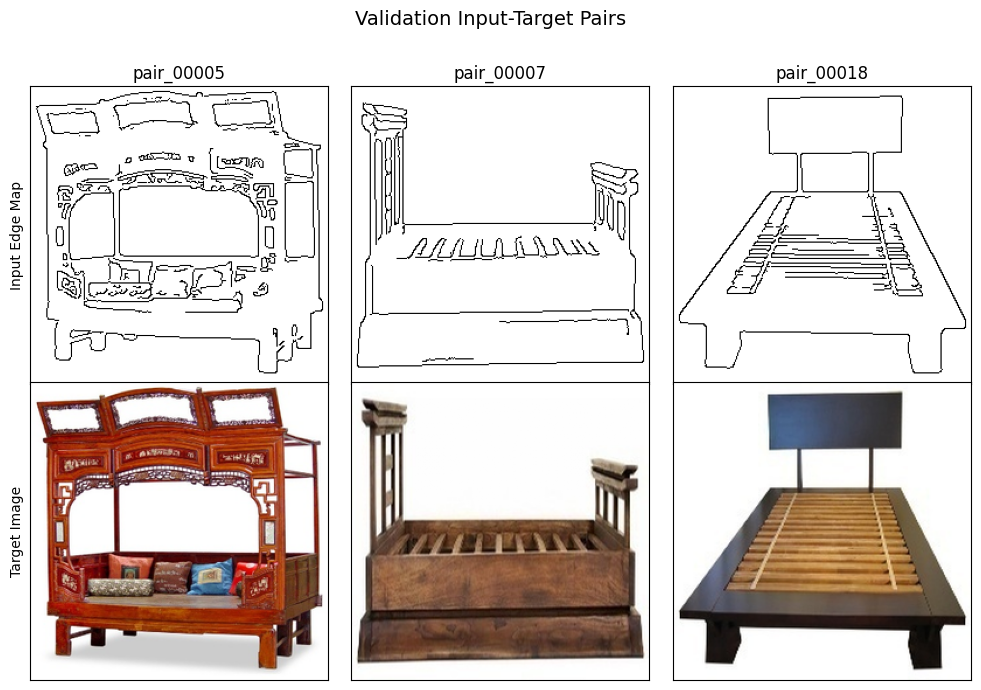

In [13]:
# Visualize a Validation Batch

NUM_PREVIEW_PAIRS = 3


def denormalize_image(tensor):
    return (
        tensor.detach()
        .cpu()
        .add(1)
        .div(2)
        .clamp(0, 1)
    )


num_preview_pairs = min(
    NUM_PREVIEW_PAIRS,
    validation_batch["input"].shape[0],
)

fig, axes = plt.subplots(
    nrows=2,
    ncols=num_preview_pairs,
    figsize=(10, 7),
    squeeze=False,
)

for index in range(num_preview_pairs):
    input_image = denormalize_image(
        validation_batch["input"][index]
    ).squeeze(0)

    target_image = denormalize_image(
        validation_batch["target"][index]
    ).permute(1, 2, 0)

    pair_id = validation_batch["pair_id"][index]

    axes[0, index].imshow(
        input_image,
        cmap="gray",
        vmin=0,
        vmax=1,
    )
    axes[0, index].set_title(str(pair_id))

    axes[1, index].imshow(target_image)

    for row_index in range(2):
        axes[row_index, index].set_xticks([])
        axes[row_index, index].set_yticks([])

axes[0, 0].set_ylabel("Input Edge Map")
axes[1, 0].set_ylabel("Target Image")

fig.suptitle("Validation Input-Target Pairs", fontsize=14)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## Model Architecture

Pix2Pix combines a U-Net generator with a PatchGAN discriminator. The generator uses the same architecture as the reconstruction baseline but is initialized from scratch, with no transfer of the baseline weights.

In [16]:
# Define Weight Initialization


def initialize_weights(module):
    if isinstance(
        module,
        (nn.Conv2d, nn.ConvTranspose2d),
    ):
        nn.init.normal_(
            module.weight,
            mean=0.0,
            std=0.02,
        )

        if module.bias is not None:
            nn.init.zeros_(module.bias)

    elif isinstance(module, nn.BatchNorm2d):
        nn.init.normal_(
            module.weight,
            mean=1.0,
            std=0.02,
        )
        nn.init.zeros_(module.bias)

In [17]:
# Define U-Net Generator


class DownsampleBlock(nn.Module):
    def __init__(
        self,
        in_channels,
        out_channels,
        apply_batch_norm=True,
    ):
        super().__init__()

        layers = [
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=not apply_batch_norm,
            ),
        ]

        if apply_batch_norm:
            layers.append(nn.BatchNorm2d(out_channels))

        layers.append(
            nn.LeakyReLU(
                negative_slope=0.2,
                inplace=True,
            )
        )

        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class UpsampleBlock(nn.Module):
    def __init__(
        self,
        in_channels,
        out_channels,
        apply_dropout=False,
    ):
        super().__init__()

        layers = [
            nn.ConvTranspose2d(
                in_channels,
                out_channels,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False,
            ),
            nn.BatchNorm2d(out_channels),
        ]

        if apply_dropout:
            layers.append(nn.Dropout(0.5))

        layers.append(nn.ReLU(inplace=True))

        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class UNetGenerator(nn.Module):
    def __init__(
        self,
        input_channels=1,
        output_channels=3,
    ):
        super().__init__()

        self.down1 = DownsampleBlock(
            input_channels,
            64,
            apply_batch_norm=False,
        )
        self.down2 = DownsampleBlock(64, 128)
        self.down3 = DownsampleBlock(128, 256)
        self.down4 = DownsampleBlock(256, 512)
        self.down5 = DownsampleBlock(512, 512)
        self.down6 = DownsampleBlock(512, 512)
        self.down7 = DownsampleBlock(512, 512)
        self.down8 = DownsampleBlock(
            512,
            512,
            apply_batch_norm=False,
        )

        self.up1 = UpsampleBlock(
            512,
            512,
            apply_dropout=True,
        )
        self.up2 = UpsampleBlock(
            1024,
            512,
            apply_dropout=True,
        )
        self.up3 = UpsampleBlock(
            1024,
            512,
            apply_dropout=True,
        )
        self.up4 = UpsampleBlock(1024, 512)
        self.up5 = UpsampleBlock(1024, 256)
        self.up6 = UpsampleBlock(512, 128)
        self.up7 = UpsampleBlock(256, 64)

        self.output_layer = nn.Sequential(
            nn.ConvTranspose2d(
                128,
                output_channels,
                kernel_size=4,
                stride=2,
                padding=1,
            ),
            nn.Tanh(),
        )

    def forward(self, x):
        down1 = self.down1(x)
        down2 = self.down2(down1)
        down3 = self.down3(down2)
        down4 = self.down4(down3)
        down5 = self.down5(down4)
        down6 = self.down6(down5)
        down7 = self.down7(down6)
        bottleneck = self.down8(down7)

        up1 = torch.cat(
            [self.up1(bottleneck), down7],
            dim=1,
        )
        up2 = torch.cat(
            [self.up2(up1), down6],
            dim=1,
        )
        up3 = torch.cat(
            [self.up3(up2), down5],
            dim=1,
        )
        up4 = torch.cat(
            [self.up4(up3), down4],
            dim=1,
        )
        up5 = torch.cat(
            [self.up5(up4), down3],
            dim=1,
        )
        up6 = torch.cat(
            [self.up6(up5), down2],
            dim=1,
        )
        up7 = torch.cat(
            [self.up7(up6), down1],
            dim=1,
        )

        return self.output_layer(up7)

In [18]:
# Initialize and Verify Generator

generator = UNetGenerator(
    input_channels=1,
    output_channels=3,
).to(DEVICE)

generator.apply(initialize_weights)
generator.eval()

generator_parameter_count = sum(
    parameter.numel()
    for parameter in generator.parameters()
)

expected_parameter_count = 54412483

if generator_parameter_count != expected_parameter_count:
    raise ValueError(
        "Unexpected generator parameter count: "
        f"{generator_parameter_count}"
    )

if any(
    isinstance(module, nn.BatchNorm2d)
    for module in generator.down8.modules()
):
    raise ValueError("The bottleneck should not contain batch normalization.")

if any(
    isinstance(module, nn.ReLU)
    for module in generator.output_layer.modules()
):
    raise ValueError("The output layer should not contain ReLU.")

with torch.no_grad():
    sample_output = generator(
        validation_batch["input"][:1].to(DEVICE)
    )

expected_output_shape = (1, 3, 256, 256)

if sample_output.shape != expected_output_shape:
    raise ValueError(
        "Unexpected generator output shape: "
        f"{sample_output.shape}"
    )

print(f"Generator parameters: {generator_parameter_count}")
print("Bottleneck batch normalization: disabled")
print("Output-layer ReLU: absent")
print(f"Generator output shape: {sample_output.shape}")

Generator parameters: 54412483
Bottleneck batch normalization: disabled
Output-layer ReLU: absent
Generator output shape: torch.Size([1, 3, 256, 256])


The PatchGAN discriminator receives each edge map concatenated with either its real target or a generated image. Instead of classifying the complete image, it evaluates overlapping local patches and produces a $30 \times 30$ map of logits. No sigmoid activation is included because the adversarial loss will use `BCEWithLogitsLoss`.

In [19]:
# Define PatchGAN Discriminator


class DiscriminatorBlock(nn.Module):
    def __init__(
        self,
        in_channels,
        out_channels,
        stride=2,
        apply_batch_norm=True,
    ):
        super().__init__()

        layers = [
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=4,
                stride=stride,
                padding=1,
                bias=not apply_batch_norm,
            ),
        ]

        if apply_batch_norm:
            layers.append(nn.BatchNorm2d(out_channels))

        layers.append(
            nn.LeakyReLU(
                negative_slope=0.2,
                inplace=True,
            )
        )

        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class PatchGANDiscriminator(nn.Module):
    def __init__(
        self,
        input_channels=1,
        target_channels=3,
    ):
        super().__init__()

        combined_channels = (input_channels + target_channels)

        self.block1 = DiscriminatorBlock(
            combined_channels,
            64,
            apply_batch_norm=False,
        )
        self.block2 = DiscriminatorBlock(64, 128)
        self.block3 = DiscriminatorBlock(128, 256)
        self.block4 = DiscriminatorBlock(256, 512, stride=1)

        self.output_layer = nn.Conv2d(
            512,
            1,
            kernel_size=4,
            stride=1,
            padding=1,
        )

    def forward(
        self,
        input_image,
        target_image,
    ):
        combined = torch.cat(
            [input_image, target_image],
            dim=1,
        )

        x = self.block1(combined)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)

        return self.output_layer(x)

In [20]:
# Initialize and Verify Discriminator

discriminator = PatchGANDiscriminator(
    input_channels=1,
    target_channels=3,
).to(DEVICE)

discriminator.apply(initialize_weights)
discriminator.eval()

discriminator_parameter_count = sum(
    parameter.numel()
    for parameter in discriminator.parameters()
)

expected_parameter_count = 2766657

if (
    discriminator_parameter_count
    != expected_parameter_count
):
    raise ValueError(
        "Unexpected discriminator parameter count: "
        f"{discriminator_parameter_count}"
    )

sample_input = (
    validation_batch["input"][:1]
    .to(DEVICE)
)

sample_target = (
    validation_batch["target"][:1]
    .to(DEVICE)
)

with torch.no_grad():
    sample_patch_logits = discriminator(
        sample_input,
        sample_target,
    )

expected_patch_shape = (1, 1, 30, 30)

if sample_patch_logits.shape != expected_patch_shape:
    raise ValueError(
        "Unexpected discriminator output shape: "
        f"{sample_patch_logits.shape}"
    )

if any(
    isinstance(module, nn.Sigmoid)
    for module in discriminator.modules()
):
    raise ValueError(
        "The discriminator should not contain sigmoid."
    )

print(
    "Discriminator parameters: "
    f"{discriminator_parameter_count}"
)
print(
    "Discriminator output shape: "
    f"{sample_patch_logits.shape}"
)
print("Output-layer sigmoid: absent")

Discriminator parameters: 2766657
Discriminator output shape: torch.Size([1, 1, 30, 30])
Output-layer sigmoid: absent


## Training Configuration

Pix2Pix is trained as a two-player game between the generator $G$ and the discriminator $D$. The edge map is denoted by $x$, the real photograph by $y$, and the generated image by $G(x)$. The theoretical Pix2Pix objective is

$$G^{*} = \arg\min_{G} \max_{D} \left[ \mathcal{L}_{\mathrm{cGAN}}(G,D) + \lambda \mathcal{L}_{L_1}(G) \right].$$

In practice, this objective is optimized through alternating discriminator and generator updates.

### Discriminator Objective

The discriminator receives the edge map concatenated with either the real photograph or the generated image and learns to distinguish between the two. Binary cross-entropy is applied to its patch logits against a target of $1$ for real pairs and $0$ for generated pairs:

$$\mathcal{L}_{D} = \frac{1}{2} \left[ \mathrm{BCE}\left(D(x,y),1\right) + \mathrm{BCE}\left(D(x,G(x)),0\right) \right].$$

The factor $\frac{1}{2}$ averages the real and generated components of the discriminator loss, following the training convention described in the original Pix2Pix work. The generated image is detached before the second term is calculated so that the discriminator update does not propagate gradients into the generator.

### Generator Objective

The generator is trained so that the discriminator classifies its output as real. The practical non-saturating adversarial loss scores generated pairs against a target of $1$:

$$\mathcal{L}_{G,\mathrm{adv}} = \mathrm{BCE}\left(D(x,G(x)),1\right).$$

A reconstruction term is added so that the generated output remains close to the target photograph. Because `L1Loss` uses mean reduction, this term is calculated as

$$\mathcal{L}_{G,L_1} = \frac{1}{N} \sum_{i=1}^{N} \left| y_i - G(x)_i \right|.$$

The adversarial and reconstruction terms are combined using the weight $\lambda$:

$$\mathcal{L}_{G} = \mathcal{L}_{G,\mathrm{adv}} + \lambda \mathcal{L}_{G,L_1}.$$

### Weighting and Optimizers

The value of `LAMBDA_L1` is set to $100$, as in the original Pix2Pix work. The adversarial term encourages local realism, sharpness, and plausible colour, while the $L_1$ term anchors the generated image to the target's global structure and appearance. The large weight reflects the different scales on which the two losses operate.

Both networks use Adam with a learning rate of $0.0002$ and beta values of $0.5$ and $0.999$, matching the settings used for the reconstruction baseline so that the comparison isolates the effect of adversarial training.

In [21]:
# Configure Losses and Optimizers

LEARNING_RATE = 0.0002
BETA1 = 0.5
BETA2 = 0.999
LAMBDA_L1 = 100.0

adversarial_criterion = nn.BCEWithLogitsLoss()
reconstruction_criterion = nn.L1Loss()

generator_optimizer = torch.optim.Adam(
    generator.parameters(),
    lr=LEARNING_RATE,
    betas=(BETA1, BETA2),
)

discriminator_optimizer = torch.optim.Adam(
    discriminator.parameters(),
    lr=LEARNING_RATE,
    betas=(BETA1, BETA2),
)

print(f"Learning rate: {LEARNING_RATE}")
print(f"Adam betas: ({BETA1}, {BETA2})")
print(f"L1 loss weight: {LAMBDA_L1}")
print(
    "Adversarial criterion: "
    f"{adversarial_criterion.__class__.__name__}"
)
print(
    "Reconstruction criterion: "
    f"{reconstruction_criterion.__class__.__name__}"
)

Learning rate: 0.0002
Adam betas: (0.5, 0.999)
L1 loss weight: 100.0
Adversarial criterion: BCEWithLogitsLoss
Reconstruction criterion: L1Loss


In [22]:
# Configure Mixed Precision
generator_scaler = torch.amp.GradScaler(
    "cuda",
    enabled=USE_AMP,
)
discriminator_scaler = torch.amp.GradScaler(
    "cuda",
    enabled=USE_AMP,
)

print(f"Mixed precision enabled: {USE_AMP}")
print(f"Autocast dtype: {AMP_DTYPE}")

Mixed precision enabled: True
Autocast dtype: torch.float16



## Training and Validation Functions

The following functions implement the discriminator and generator objectives defined above. The individual loss components are returned separately so that they can be monitored throughout training and validation.

In [23]:
# Define Loss Functions


def calculate_discriminator_loss(
    real_logits,
    generated_logits,
):
    real_loss = adversarial_criterion(
        real_logits,
        torch.ones_like(real_logits),
    )

    generated_loss = adversarial_criterion(
        generated_logits,
        torch.zeros_like(generated_logits),
    )

    total_loss = 0.5 * (real_loss + generated_loss)

    return (
        total_loss,
        real_loss,
        generated_loss,
    )


def calculate_generator_loss(
    generated_logits,
    generated_images,
    target_images,
):
    adversarial_loss = adversarial_criterion(
        generated_logits,
        torch.ones_like(generated_logits),
    )

    reconstruction_loss = reconstruction_criterion(
        generated_images,
        target_images,
    )

    total_loss = (adversarial_loss + LAMBDA_L1 * reconstruction_loss)

    return (
        total_loss,
        adversarial_loss,
        reconstruction_loss,
    )

In [24]:
# Define Training Batch Function


def set_requires_grad(
    model,
    requires_grad,
):
    for parameter in model.parameters():
        parameter.requires_grad_(requires_grad)


def train_batch(
    input_images,
    target_images,
):
    generator.train()
    discriminator.train()

    input_images = input_images.to(DEVICE, non_blocking=True)
    target_images = target_images.to(DEVICE, non_blocking=True)

    generator_optimizer.zero_grad(set_to_none=True)
    discriminator_optimizer.zero_grad(set_to_none=True)

    # Update Discriminator

    set_requires_grad(discriminator, True)

    with torch.autocast(
        device_type=DEVICE.type,
        dtype=AMP_DTYPE,
        enabled=USE_AMP,
    ):
        generated_images = generator(
            input_images
        )

        real_logits = discriminator(
            input_images,
            target_images,
        )

        generated_logits = discriminator(
            input_images,
            generated_images.detach(),
        )

        (
            discriminator_loss,
            discriminator_real_loss,
            discriminator_generated_loss,
        ) = calculate_discriminator_loss(
            real_logits,
            generated_logits,
        )

    discriminator_scaler.scale(discriminator_loss).backward()

    discriminator_scaler.step(discriminator_optimizer)
    discriminator_scaler.update()

    # Update Generator

    set_requires_grad(discriminator, False)

    with torch.autocast(
        device_type=DEVICE.type,
        dtype=AMP_DTYPE,
        enabled=USE_AMP,
    ):
        generated_logits = discriminator(
            input_images,
            generated_images,
        )

        (
            generator_loss,
            generator_adversarial_loss,
            generator_reconstruction_loss,
        ) = calculate_generator_loss(
            generated_logits,
            generated_images,
            target_images,
        )

    generator_scaler.scale(generator_loss).backward()

    generator_scaler.step(generator_optimizer)
    generator_scaler.update()

    set_requires_grad(discriminator, True)


    return {
        "generator_loss": (generator_loss.detach()),
        "generator_adversarial_loss": (generator_adversarial_loss.detach()),
        "generator_reconstruction_loss": (generator_reconstruction_loss.detach()),
        "discriminator_loss": (discriminator_loss.detach()),
        "discriminator_real_loss": (discriminator_real_loss.detach()),
        "discriminator_generated_loss": (discriminator_generated_loss.detach()),
    }

In [25]:
# Define Validation Batch Function


@torch.inference_mode()
def validate_batch(
    input_images,
    target_images,
):
    generator.eval()
    discriminator.eval()

    input_images = input_images.to(DEVICE, non_blocking=True)
    target_images = target_images.to(DEVICE, non_blocking=True)

    with torch.autocast(
        device_type=DEVICE.type,
        dtype=AMP_DTYPE,
        enabled=USE_AMP,
    ):
        generated_images = generator(input_images)

        real_logits = discriminator(input_images, target_images)

        generated_logits = discriminator(input_images, generated_images)

        (
            discriminator_loss,
            discriminator_real_loss,
            discriminator_generated_loss,
        ) = calculate_discriminator_loss(
            real_logits,
            generated_logits,
        )

        (
            generator_loss,
            generator_adversarial_loss,
            generator_reconstruction_loss,
        ) = calculate_generator_loss(
            generated_logits,
            generated_images,
            target_images,
        )

    return {
        "generator_loss": (generator_loss.detach()),
        "generator_adversarial_loss": (generator_adversarial_loss.detach()),
        "generator_reconstruction_loss": (generator_reconstruction_loss.detach()),
        "discriminator_loss": (discriminator_loss.detach()),
        "discriminator_real_loss": (discriminator_real_loss.detach()),
        "discriminator_generated_loss": (discriminator_generated_loss.detach()),
    }

In [26]:
# Define Epoch Function

LOSS_NAMES = (
    "generator_loss",
    "generator_adversarial_loss",
    "generator_reconstruction_loss",
    "discriminator_loss",
    "discriminator_real_loss",
    "discriminator_generated_loss",
)


def run_epoch(
    data_loader,
    training,
    max_batches=None,
):
    if (max_batches is not None and max_batches < 1):
        raise ValueError("max_batches must be at least 1.")

    accumulated_losses = torch.zeros(
        len(LOSS_NAMES),
        device=DEVICE,
        dtype=torch.float32,
    )

    total_samples = 0

    batch_function = (train_batch if training else validate_batch)

    description = ("Training" if training else "Validation")

    for batch_number, batch in enumerate(
        tqdm(
            data_loader,
            desc=description,
            leave=False,
        ),
        start=1,
    ):
        input_images = batch["input"]
        target_images = batch["target"]

        batch_size = input_images.size(0)

        batch_losses = batch_function(input_images, target_images)

        loss_vector = torch.stack(
            [
                batch_losses[name].float()
                for name in LOSS_NAMES
            ]
        )

        accumulated_losses += (loss_vector * batch_size)
        total_samples += batch_size

        if (max_batches is not None and batch_number >= max_batches):
            break

    if total_samples == 0:
        raise ValueError("The data loader contains no samples.")

    average_losses = (
        accumulated_losses
        .div(total_samples)
        .cpu()
        .tolist()
    )

    return dict(
        zip(
            LOSS_NAMES,
            average_losses,
        )
    )

In [27]:
# Define Training History Utilities


def initialize_training_history():
    history = {
        "epoch": [],
        "epoch_seconds": [],
    }

    for split_name in (
        "train",
        "validation",
    ):
        for loss_name in LOSS_NAMES:
            history[
                f"{split_name}_{loss_name}"
            ] = []

    return history


def update_training_history(
    history,
    epoch,
    training_losses,
    validation_losses,
    epoch_seconds,
):
    history["epoch"].append(int(epoch))
    history["epoch_seconds"].append(float(epoch_seconds))


    for loss_name in LOSS_NAMES:
        history[
            f"train_{loss_name}"
        ].append(
            float(training_losses[loss_name])
        )

        history[
            f"validation_{loss_name}"
        ].append(
            float(validation_losses[loss_name])
        )

In [28]:
# Configure Checkpoint Paths

LATEST_CHECKPOINT_PATH = (
    CKPT_DIR
    / "latest_checkpoint.pt"
)

BEST_GENERATOR_PATH = (
    CKPT_DIR
    / "best_generator.pt"
)

print(f"Latest checkpoint: {LATEST_CHECKPOINT_PATH}")
print(f"Best generator: {BEST_GENERATOR_PATH}")

Latest checkpoint: /content/drive/MyDrive/Sketch2Furniture/checkpoints/pix2pix/latest_checkpoint.pt
Best generator: /content/drive/MyDrive/Sketch2Furniture/checkpoints/pix2pix/best_generator.pt


In [29]:
# Define Checkpoint Helpers
def save_latest_checkpoint(
    epoch,
    history,
    best_validation_reconstruction_loss,
):
    checkpoint = {
        "epoch": int(epoch),
        "generator_state_dict": (
            generator.state_dict()
        ),
        "discriminator_state_dict": (
            discriminator.state_dict()
        ),
        "generator_optimizer_state_dict": (
            generator_optimizer.state_dict()
        ),
        "discriminator_optimizer_state_dict": (
            discriminator_optimizer.state_dict()
        ),
        "generator_scaler_state_dict": (
            generator_scaler.state_dict()
        ),
        "discriminator_scaler_state_dict": (
            discriminator_scaler.state_dict()
        ),
        "history": history,
        "best_validation_reconstruction_loss": float(
            best_validation_reconstruction_loss
        ),
    }
    torch.save(checkpoint, LATEST_CHECKPOINT_PATH)


def save_best_generator():
    torch.save(
        generator.state_dict(),
        BEST_GENERATOR_PATH,
    )


def load_latest_checkpoint():
    if not LATEST_CHECKPOINT_PATH.exists():
        raise FileNotFoundError(
            "Latest Pix2Pix checkpoint not found: "
            f"{LATEST_CHECKPOINT_PATH}"
        )
    checkpoint = torch.load(
        LATEST_CHECKPOINT_PATH,
        map_location=DEVICE,
        weights_only=True,
    )
    generator.load_state_dict(
        checkpoint["generator_state_dict"]
    )
    discriminator.load_state_dict(
        checkpoint["discriminator_state_dict"]
    )
    generator_optimizer.load_state_dict(
        checkpoint[
            "generator_optimizer_state_dict"
        ]
    )
    discriminator_optimizer.load_state_dict(
        checkpoint[
            "discriminator_optimizer_state_dict"
        ]
    )
    if generator_scaler.is_enabled():
        generator_scaler.load_state_dict(
            checkpoint[
                "generator_scaler_state_dict"
            ]
        )
        discriminator_scaler.load_state_dict(
            checkpoint[
                "discriminator_scaler_state_dict"
            ]
        )
    start_epoch = (
        int(checkpoint["epoch"]) + 1
    )
    history = checkpoint["history"]
    best_validation_reconstruction_loss = float(
        checkpoint[
            "best_validation_reconstruction_loss"
        ]
    )
    return (
        start_epoch,
        history,
        best_validation_reconstruction_loss,
    )

### Utility Design

The training utilities separate the discriminator and generator updates, validation, epoch-level aggregation, history tracking, and checkpoint management. Losses are accumulated on the GPU and transferred to the CPU only once per epoch to reduce synchronization overhead. The best generator is selected using validation reconstruction loss rather than total generator loss. The adversarial component decreases when generated pairs fool the current discriminator, which does not necessarily indicate improved image quality. Reconstruction loss provides a more stable model-selection criterion and is directly comparable with the reconstruction baseline.

In [30]:
# Define Training Loop

def train_pix2pix(
    training_loader,
    validation_loader,
    total_epochs,
    start_epoch=1,
    history=None,
    best_validation_reconstruction_loss=float("inf"),
    save_checkpoints=True,
    max_batches=None,
):
    if total_epochs < 1:
        raise ValueError("total_epochs must be at least 1.")

    if history is None:
        history = initialize_training_history()

    for epoch in range(
        start_epoch,
        total_epochs + 1,
    ):
        print(
            f"Epoch {epoch}/{total_epochs}",
            flush=True,
        )

        epoch_start = time.perf_counter()

        training_losses = run_epoch(
            training_loader,
            training=True,
            max_batches=max_batches,
        )

        validation_losses = run_epoch(
            validation_loader,
            training=False,
            max_batches=max_batches,
        )

        epoch_seconds = (
            time.perf_counter() - epoch_start
        )

        update_training_history(
            history=history,
            epoch=epoch,
            training_losses=training_losses,
            validation_losses=validation_losses,
            epoch_seconds=epoch_seconds,
        )

        current_validation_reconstruction_loss = (
            validation_losses[
                "generator_reconstruction_loss"
            ]
        )

        is_best = (
            current_validation_reconstruction_loss
            < best_validation_reconstruction_loss
        )

        if is_best:
            best_validation_reconstruction_loss = (
                current_validation_reconstruction_loss
            )

            if save_checkpoints:
                save_best_generator()

        if save_checkpoints:
            save_latest_checkpoint(
                epoch=epoch,
                history=history,
                best_validation_reconstruction_loss=(
                    best_validation_reconstruction_loss
                ),
            )

        best_marker = (
            " | Best generator"
            if is_best
            else ""
        )

        print(
            f"Train G: "
            f"{training_losses['generator_loss']:.4f} | "
            f"Validation G: "
            f"{validation_losses['generator_loss']:.4f} | "
            f"Validation L1: "
            f"{current_validation_reconstruction_loss:.4f} | "
            f"Train D: "
            f"{training_losses['discriminator_loss']:.4f} | "
            f"Validation D: "
            f"{validation_losses['discriminator_loss']:.4f} | "
            f"Time: {epoch_seconds:.1f}s"
            f"{best_marker}"
        )
        print()

    return (history, best_validation_reconstruction_loss)

## Training Pipeline Test

Before full training, the training pipeline is tested on a limited number of batches to verify the model updates, loss calculations, GPU memory usage, runtime, and generated outputs.

In [31]:
# Configure Training Pipeline Test

PIPELINE_TEST_EPOCHS = 1
PIPELINE_TEST_MAX_BATCHES = 5

print(f"Pipeline test epochs: {PIPELINE_TEST_EPOCHS}")
print(f"Maximum batches per split: {PIPELINE_TEST_MAX_BATCHES}")

Pipeline test epochs: 1
Maximum batches per split: 5


In [32]:
# Run Training Pipeline Test

if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()

pipeline_test_history, (
    pipeline_test_best_validation_reconstruction_loss
) = train_pix2pix(
    training_loader=train_loader,
    validation_loader=validation_loader,
    total_epochs=PIPELINE_TEST_EPOCHS,
    save_checkpoints=False,
    max_batches=PIPELINE_TEST_MAX_BATCHES,
)

if torch.cuda.is_available():
    peak_gpu_memory_gb = (
        torch.cuda.max_memory_allocated()
        / 1024**3
    )

    print(f"Peak GPU memory allocated: {peak_gpu_memory_gb:.2f} GB")

Epoch 1/1


Training:   0%|          | 0/1215 [00:00<?, ?it/s]

Validation:   0%|          | 0/214 [00:00<?, ?it/s]

Train G: 72.1640 | Validation G: 70.9388 | Validation L1: 0.7009 | Train D: 0.8267 | Validation D: 0.6794 | Time: 2.9s | Best generator

Peak GPU memory allocated: 9.00 GB


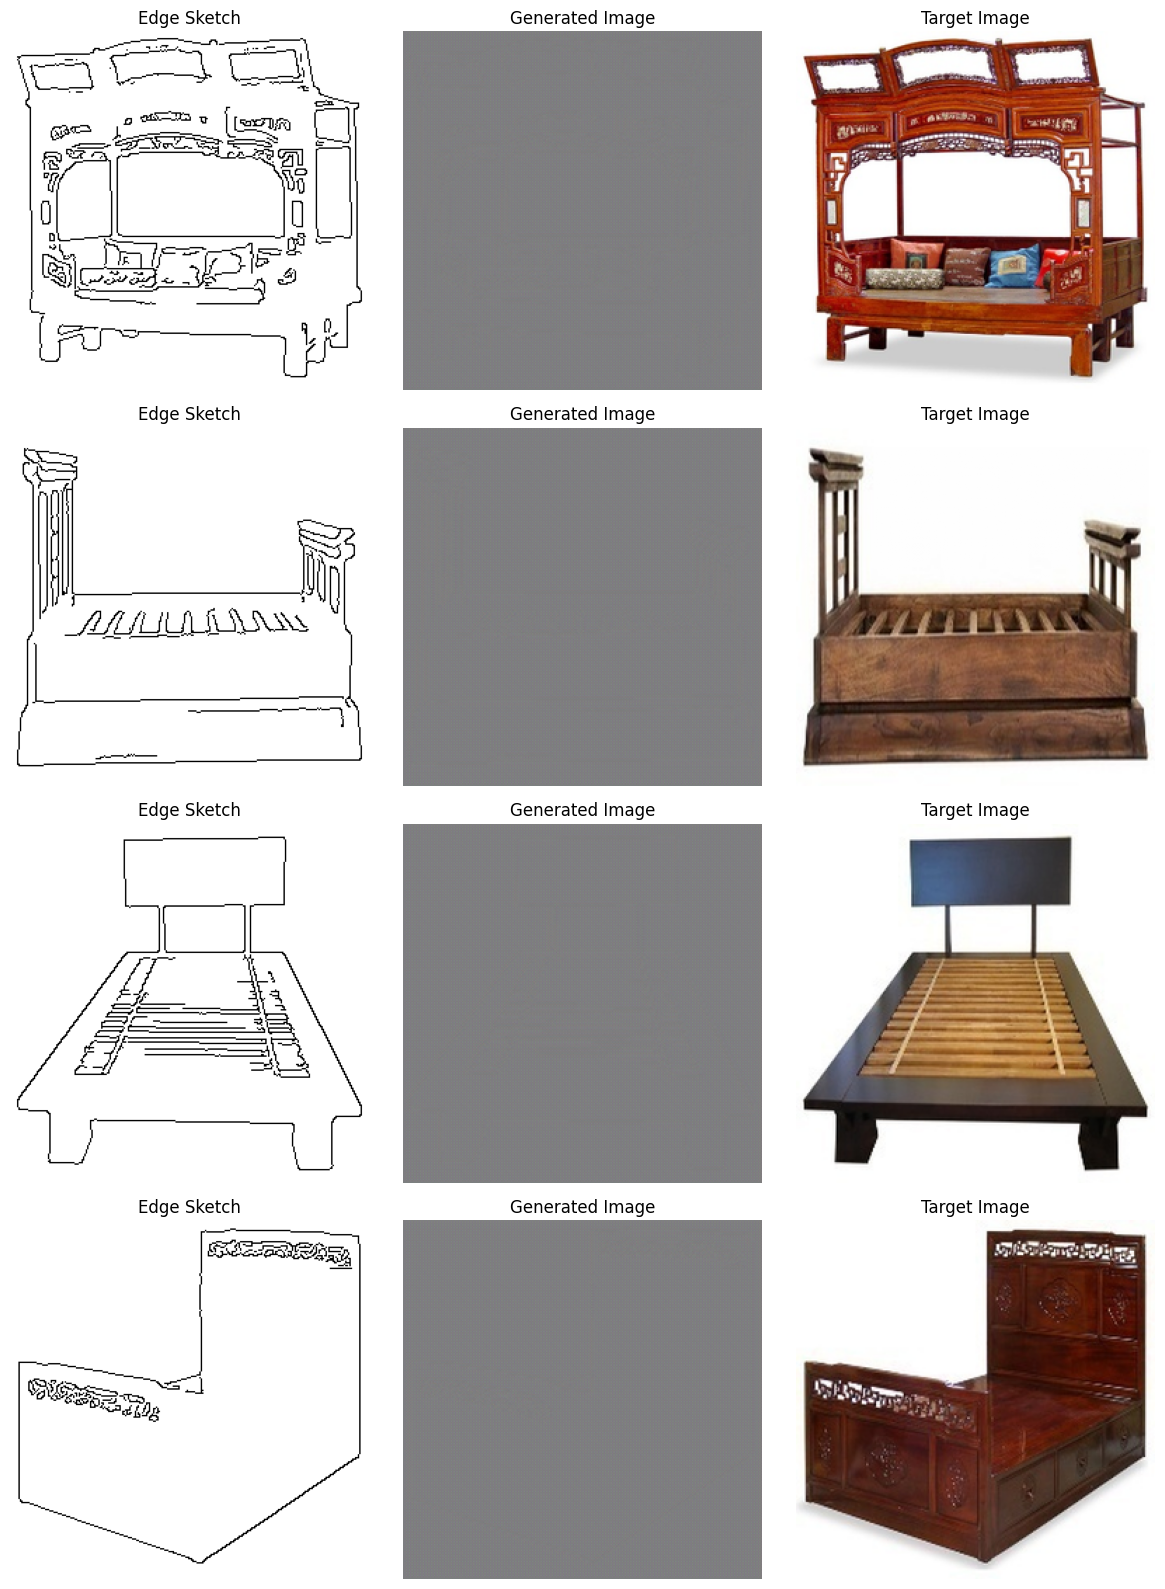

In [33]:
# Inspect Pipeline Test Outputs

generator_was_training = generator.training
generator.eval()

validation_batch = next(iter(validation_loader))

input_images = validation_batch[
    "input"
].to(DEVICE)

target_images = validation_batch[
    "target"
].to(DEVICE)

with torch.no_grad():
    generated_images = generator(
        input_images
    )

if generator_was_training:
    generator.train()

number_of_examples = min(
    4,
    input_images.size(0),
)

figure, axes = plt.subplots(
    number_of_examples,
    3,
    figsize=(12, 4 * number_of_examples),
    squeeze=False,
)

titles = (
    "Edge Sketch",
    "Generated Image",
    "Target Image",
)

for index in range(number_of_examples):
    images = (
        input_images[index],
        generated_images[index],
        target_images[index],
    )

    for column, (
        image,
        title,
    ) in enumerate(
        zip(images, titles)
    ):
        display_image = (
            denormalize_image(
                image.detach()
            )
            .cpu()
            .permute(1, 2, 0)
            .numpy()
        )

        if display_image.shape[-1] == 1:
            axes[index, column].imshow(
                display_image.squeeze(-1),
                cmap="gray",
                vmin=0,
                vmax=1,
            )
        else:
            axes[index, column].imshow(
                display_image
            )

        axes[index, column].set_title(
            title
        )
        axes[index, column].axis("off")


plt.tight_layout()
plt.show()

### Observation

The limited training pipeline test completed successfully without runtime, out-of-memory, or numerical errors, using a peak of 9.00 GB of allocated GPU memory. The test loss values were consistent with a model near random initialization: the discriminator loss of 0.6794 was close to $\ln 2 \approx 0.693$, the value expected when its logits carry little useful information, while the reconstruction loss of 0.7009 matched the value measured for the untrained baseline in Notebook 03.

The generator produced correctly shaped outputs, but the images remained nearly uniform gray and did not yet reconstruct the furniture structure. This was expected because the model had been trained for only five batches from random initialization. The test therefore verified the functionality and computational feasibility of the training pipeline rather than the visual quality of the generated images.

In [35]:
# Clear Training Pipeline Test Outputs


def clear_training_pipeline_test_outputs():
    required_training_components = (
        "generator",
        "discriminator",
        "generator_optimizer",
        "discriminator_optimizer",
        "generator_scaler",
        "discriminator_scaler",
    )

    missing_components = [
        component_name
        for component_name
        in required_training_components
        if component_name not in globals()
    ]

    if missing_components:
        raise RuntimeError(
            "Required training components are missing: "
            + ", ".join(missing_components)
        )

    if "figure" in globals():
        plt.close(
            globals()["figure"]
        )

    temporary_names = (
        "pipeline_test_history",
        "pipeline_test_best_validation_reconstruction_loss",
        "validation_batch",
        "input_images",
        "target_images",
        "generated_images",
        "generator_was_training",
        "number_of_examples",
        "figure",
        "axes",
        "titles",
        "index",
        "images",
        "column",
        "image",
        "title",
        "display_image",
        "peak_gpu_memory_gb",
    )

    for temporary_name in temporary_names:
        globals().pop(
            temporary_name,
            None,
        )

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()

    print(
        "Training pipeline test outputs cleared."
    )
    print(
        "Models, optimizers, and scalers preserved "
        "until rebuilding."
    )


clear_training_pipeline_test_outputs()


Training pipeline test outputs cleared.
Models, optimizers, and scalers preserved until rebuilding.


## Full Pix2Pix Training

Before full training, the generator, discriminator, optimizers, and gradient scalers are rebuilt. This removes all parameter updates and optimization state accumulated during the limited pipeline test, ensuring that full training begins from a freshly initialized state.

In [36]:
# Rebuild Models, Optimizers, and Scalers
generator = UNetGenerator(
    input_channels=1,
    output_channels=3,
).to(DEVICE)
discriminator = PatchGANDiscriminator(
    input_channels=1,
    target_channels=3,
).to(DEVICE)

generator.apply(initialize_weights)
discriminator.apply(initialize_weights)

generator.train()
discriminator.train()

generator_optimizer = torch.optim.Adam(
    generator.parameters(),
    lr=LEARNING_RATE,
    betas=(BETA1, BETA2),
)
discriminator_optimizer = torch.optim.Adam(
    discriminator.parameters(),
    lr=LEARNING_RATE,
    betas=(BETA1, BETA2),
)

generator_scaler = torch.amp.GradScaler(
    "cuda",
    enabled=USE_AMP,
)
discriminator_scaler = torch.amp.GradScaler(
    "cuda",
    enabled=USE_AMP,
)

print(
    "Generator parameters: "
    f"{sum(parameter.numel() for parameter in generator.parameters())}"
)
print(
    "Discriminator parameters: "
    f"{sum(parameter.numel() for parameter in discriminator.parameters())}"
)
print(
    "Generator optimizer state entries: "
    f"{len(generator_optimizer.state)}"
)
print(
    "Discriminator optimizer state entries: "
    f"{len(discriminator_optimizer.state)}"
)

Generator parameters: 54412483
Discriminator parameters: 2766657
Generator optimizer state entries: 0
Discriminator optimizer state entries: 0


Full training is performed for an absolute target of 20 epochs. If a latest checkpoint is available, the complete training state is restored and training continues from the following epoch. Otherwise, training begins from the freshly initialized models. This also makes rerunning the cell safe after training has completed.

In [37]:
# Run Full Pix2Pix Training

TOTAL_EPOCHS = 20

if LATEST_CHECKPOINT_PATH.exists():
    (
        start_epoch,
        training_history,
        best_validation_reconstruction_loss,
    ) = load_latest_checkpoint()

    print(
        "Latest checkpoint loaded. "
        f"Continuing from epoch {start_epoch}."
    )
else:
    start_epoch = 1
    training_history = (
        initialize_training_history()
    )
    best_validation_reconstruction_loss = (
        float("inf")
    )

    print(
        "No checkpoint found. "
        "Starting full training from epoch 1."
    )

training_history, (
    best_validation_reconstruction_loss
) = train_pix2pix(
    training_loader=train_loader,
    validation_loader=validation_loader,
    total_epochs=TOTAL_EPOCHS,
    start_epoch=start_epoch,
    history=training_history,
    best_validation_reconstruction_loss=(
        best_validation_reconstruction_loss
    ),
    save_checkpoints=True,
    max_batches=None,
)

No checkpoint found. Starting full training from epoch 1.
Epoch 1/20


Training:   0%|          | 0/1215 [00:00<?, ?it/s]

Validation:   0%|          | 0/214 [00:00<?, ?it/s]

Train G: 32.2374 | Validation G: 40.8223 | Validation L1: 0.3954 | Train D: 0.4387 | Validation D: 0.8104 | Time: 116.5s | Best generator

Epoch 2/20


Training:   0%|          | 0/1215 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/214 [00:00<?, ?it/s]

Train G: 28.1817 | Validation G: 27.0457 | Validation L1: 0.2549 | Train D: 0.1098 | Validation D: 0.8078 | Time: 125.1s

Epoch 20/20


Training:   0%|          | 0/1215 [00:00<?, ?it/s]

Validation:   0%|          | 0/214 [00:00<?, ?it/s]

Train G: 28.1003 | Validation G: 27.8282 | Validation L1: 0.2494 | Train D: 0.1064 | Validation D: 1.3770 | Time: 125.2s



## Training History and Loss Curves

The recorded training and validation losses are visualized across the 20 epochs to examine convergence, generalization, and the balance between the generator and discriminator. The adversarial and reconstruction components of the generator loss are also inspected separately because they represent different training objectives.

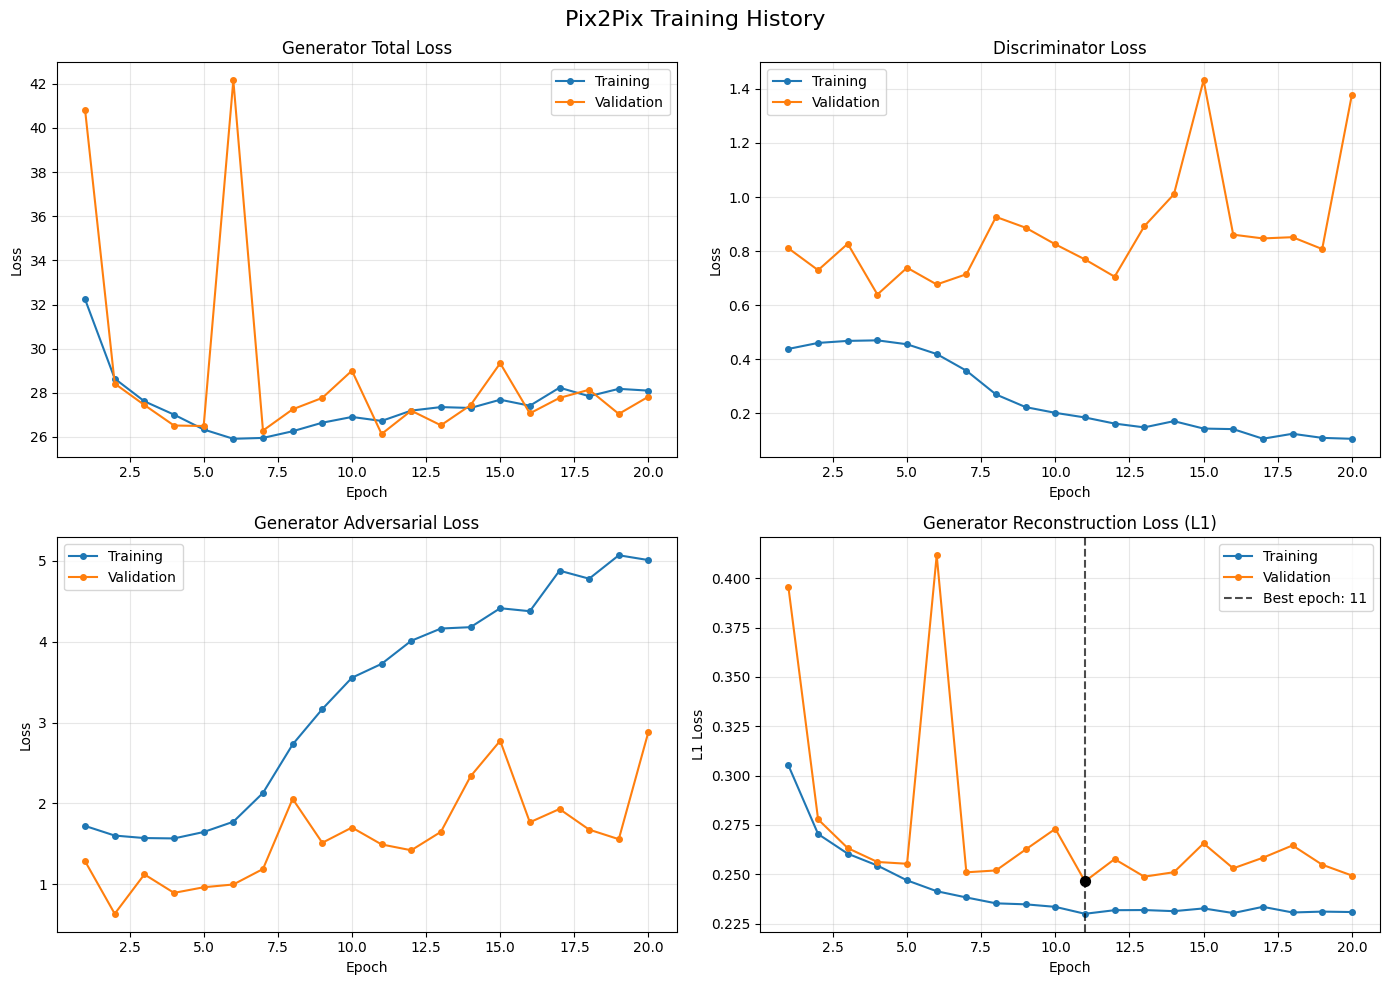

Best validation reconstruction epoch: 11
Best validation reconstruction loss: 0.2464


In [39]:
# Plot Training History and Loss Curves

epochs = training_history["epoch"]

validation_reconstruction_losses = (
    training_history[
        "validation_generator_reconstruction_loss"
    ]
)

best_history_index = min(
    range(len(epochs)),
    key=lambda index: (
        validation_reconstruction_losses[index]
    ),
)

best_epoch = epochs[best_history_index]

best_reconstruction_loss = (
    validation_reconstruction_losses[
        best_history_index
    ]
)

curve_configurations = (
    (
        "train_generator_loss",
        "validation_generator_loss",
        "Generator Total Loss",
        "Loss",
    ),
    (
        "train_discriminator_loss",
        "validation_discriminator_loss",
        "Discriminator Loss",
        "Loss",
    ),
    (
        "train_generator_adversarial_loss",
        "validation_generator_adversarial_loss",
        "Generator Adversarial Loss",
        "Loss",
    ),
    (
        "train_generator_reconstruction_loss",
        "validation_generator_reconstruction_loss",
        "Generator Reconstruction Loss (L1)",
        "L1 Loss",
    ),
)

figure, axes = plt.subplots(2, 2, figsize=(14, 10))

for axis, (
    training_key,
    validation_key,
    title,
    y_label,
) in zip(
    axes.flat,
    curve_configurations,
):
    axis.plot(
        epochs,
        training_history[training_key],
        marker="o",
        markersize=4,
        label="Training",
    )

    axis.plot(
        epochs,
        training_history[validation_key],
        marker="o",
        markersize=4,
        label="Validation",
    )

    axis.set_title(title)
    axis.set_xlabel("Epoch")
    axis.set_ylabel(y_label)
    axis.grid(alpha=0.3)
    axis.legend()

axes[1, 1].axvline(
    best_epoch,
    color="black",
    linestyle="--",
    alpha=0.7,
    label=(
        f"Best epoch: {best_epoch}"
    ),
)

axes[1, 1].scatter(
    best_epoch,
    best_reconstruction_loss,
    color="black",
    s=50,
    zorder=3,
)

axes[1, 1].legend()

figure.suptitle("Pix2Pix Training History", fontsize=16)

plt.tight_layout()

figure.savefig(
    FIGURE_DIR / "pix2pix_loss.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

print(f"Best validation reconstruction epoch: {best_epoch}")

print(f"Best validation reconstruction loss: {best_reconstruction_loss:.4f}")

## Validation Prediction

The generator checkpoint with the lowest validation reconstruction loss and the generator from the final training epoch are evaluated on the same validation examples. This comparison examines whether the best reconstruction checkpoint also produces the most visually convincing results, because a slightly higher $L_1$ loss may still be accompanied by sharper or more realistic details.

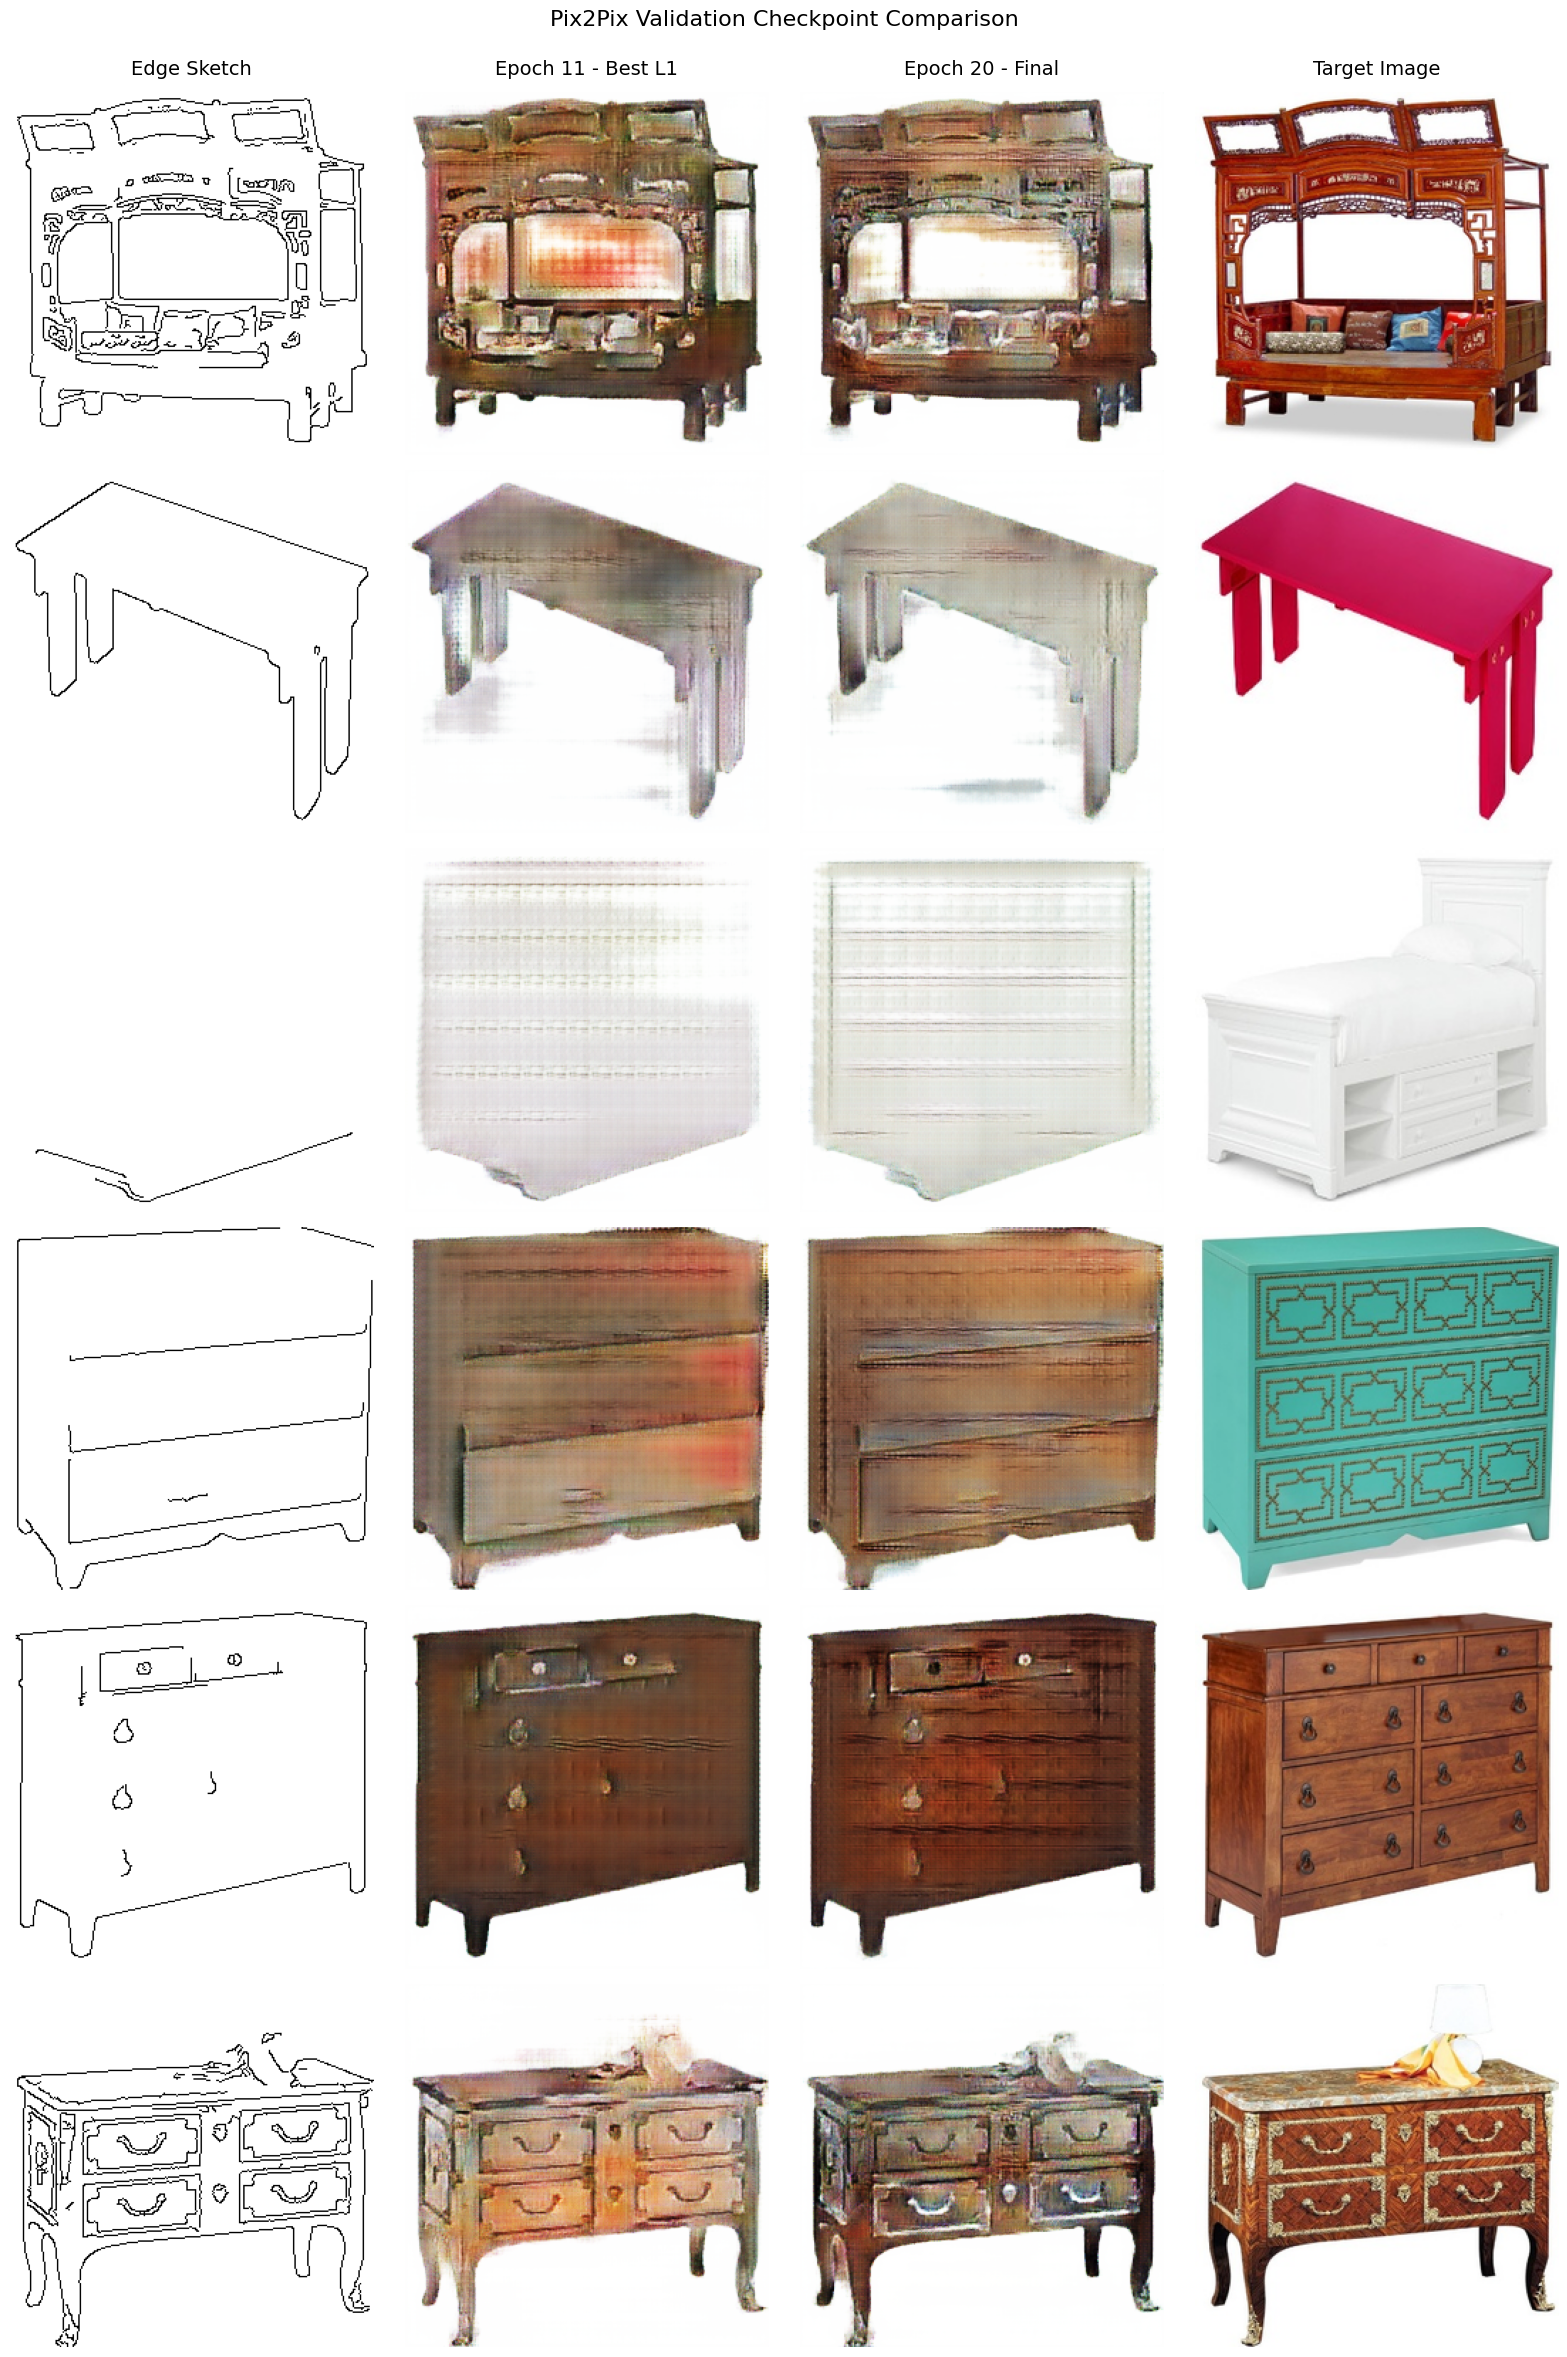

Selected validation indices: [0, 341, 683, 1024, 1366, 1707]
Selected pair IDs: ['pair_00005', 'pair_02860', 'pair_05659', 'pair_08577', 'pair_11498', 'pair_14334']
Best-L1 checkpoint: epoch 11, validation L1 0.2464
Final checkpoint: epoch 20, validation L1 0.2494
Global generator: final checkpoint
Separate best_generator: best-L1 checkpoint


In [43]:
# Compare Best and Final Generator Predictions

if not LATEST_CHECKPOINT_PATH.exists():
    raise FileNotFoundError(
        "The latest training checkpoint was not found: "
        f"{LATEST_CHECKPOINT_PATH}"
    )

if not BEST_GENERATOR_PATH.exists():
    raise FileNotFoundError(
        "The best generator checkpoint was not found: "
        f"{BEST_GENERATOR_PATH}"
    )


# Restore the final complete training checkpoint.

(
    latest_start_epoch,
    latest_training_history,
    latest_best_validation_reconstruction_loss,
) = load_latest_checkpoint()

latest_epoch = latest_start_epoch - 1

generator.eval()


# Create a separate generator for the best-L1 checkpoint.

best_generator = UNetGenerator(
    input_channels=1,
    output_channels=3,
).to(
    DEVICE
)

best_generator_state_dict = torch.load(
    BEST_GENERATOR_PATH,
    map_location="cpu",
    weights_only=True,
)

best_generator.load_state_dict(
    best_generator_state_dict
)

del best_generator_state_dict

best_generator.eval()


# Select the same evenly spaced validation examples as Notebook 03.

number_of_examples = min(
    6,
    len(validation_dataset),
)

selected_indices = (
    torch.linspace(
        0,
        len(validation_dataset) - 1,
        steps=number_of_examples,
    )
    .round()
    .long()
    .tolist()
)

selected_samples = [
    validation_dataset[index]
    for index in selected_indices
]

input_images = torch.stack(
    [
        sample["input"]
        for sample in selected_samples
    ]
).to(
    DEVICE
)

target_images = torch.stack(
    [
        sample["target"]
        for sample in selected_samples
    ]
).to(
    DEVICE
)

selected_pair_ids = [
    sample["pair_id"]
    for sample in selected_samples
]


# Generate predictions from both checkpoints.

with torch.inference_mode():
    best_generated_images = best_generator(
        input_images
    ).detach().cpu()

    final_generated_images = generator(
        input_images
    ).detach().cpu()


# Recover the selected epochs and validation losses.

history_epochs = latest_training_history[
    "epoch"
]

validation_reconstruction_losses = (
    latest_training_history[
        "validation_generator_reconstruction_loss"
    ]
)

best_history_index = min(
    range(len(history_epochs)),
    key=lambda index: (
        validation_reconstruction_losses[index]
    ),
)

best_epoch = history_epochs[best_history_index]

best_reconstruction_loss = (
    validation_reconstruction_losses[
        best_history_index
    ]
)

final_reconstruction_loss = (validation_reconstruction_losses[-1])


# Display the controlled checkpoint comparison.

comparison_figure, comparison_axes = plt.subplots(
    number_of_examples,
    4,
    figsize=(16, 4 * number_of_examples),
    squeeze=False,
)

titles = (
    "Edge Sketch",
    f"Epoch {best_epoch} - Best L1",
    f"Epoch {latest_epoch} - Final",
    "Target Image",
)

for row_index in range(number_of_examples):
    comparison_images = (
        input_images[row_index],
        best_generated_images[row_index],
        final_generated_images[row_index],
        target_images[row_index],
    )

    for column_index, image in enumerate(
        comparison_images
    ):
        display_image = (
            denormalize_image(
                image.detach()
            )
            .cpu()
            .permute(1, 2, 0)
            .numpy()
        )

        if display_image.shape[-1] == 1:
            comparison_axes[
                row_index,
                column_index,
            ].imshow(
                display_image.squeeze(-1),
                cmap="gray",
                vmin=0,
                vmax=1,
            )
        else:
            comparison_axes[
                row_index,
                column_index,
            ].imshow(
                display_image
            )



        comparison_axes[
            row_index,
            column_index,
        ].axis("off")



# Add column labels after all axes have been configured.

for column_index, title in enumerate(
    titles
):
    comparison_axes[
        0,
        column_index,
    ].set_title(
        title,
        fontsize=14,
        pad=12,
    )



comparison_figure.suptitle(
    "Pix2Pix Validation Checkpoint Comparison",
    fontsize=16,
)

plt.tight_layout(
    rect=(0, 0, 1, 0.98)
)

comparison_figure.savefig(
    FIGURE_DIR
    / "pix2pix_checkpoint_comparison.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()


print(f"Selected validation indices: {selected_indices}")

print(f"Selected pair IDs: {selected_pair_ids}")

print(
    "Best-L1 checkpoint: "
    f"epoch {best_epoch}, "
    f"validation L1 {best_reconstruction_loss:.4f}"
)

print(
    "Final checkpoint: "
    f"epoch {latest_epoch}, "
    f"validation L1 {final_reconstruction_loss:.4f}"
)

print("Global generator: final checkpoint")

print("Separate best_generator: best-L1 checkpoint")

## Initial Pix2Pix Analysis

Training remained stable across 20 epochs with no sign of generator collapse. The lowest validation $L_1$ loss was 0.2464 at epoch 11 against 0.2494 at epoch 20, a difference of 0.0030. The falling discriminator loss and rising generator adversarial loss indicate that the discriminator grew steadily more effective. These curves track progress but cannot identify the most visually convincing checkpoint.

The same six validation examples as the baseline evaluation were used. Epoch 11 produced smoother and paler images, while epoch 20 produced stronger contrast and clearer structure. Denser sketches yielded more recognizable furniture, though contours remained imprecise and fine detail blurred. For the low-contrast white bed, Canny removed most of the structure, leaving neither checkpoint enough information to reconstruct it, and its large white background also keeps $L_1$ low despite the poor result.

Inspection also revealed an ambiguity in `pair_02860`, **present in Notebook 03 but missed at the time**. The record is filed under `beds` as `4643modern-toddler-beds.jpg`, and the pairing was verified as correct, but the target lacks recognizable bed features and resembles a low table. The generator therefore had no basis for rendering a bed, and its output should not be read as confusion between the two selected categories.

An edge sketch does not determine one correct photograph. Pix2Pix produces a plausible appearance from the available contours, while colour, material, and missing structure are inferred from training patterns. Colour in particular cannot be recovered from a binary edge map, so vivid targets are reconstructed in the muted tones that dominate the training data. Epoch 11 is retained as the best checkpoint by validation $L_1$, and epoch 20 is qualitatively stronger in several examples. Both are preserved for comparison after training continues.


## Saving Models and Training Artifacts

## Conclusions and Next Steps